# HCI Car Simulation_Data Analysis

In [165]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import re
import pandas as pd
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

from scripts import twoddynamics, oneddynamics, databuilder, readsubcategoryrating, intensity_calculation


In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
# %config InlineBackend.figure_format = 'svg'

plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

# 0. Load data and write data dictionary

In [166]:
phase = "phaseI"
sub_nums = np.arange(1,23,1)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data"
data_dir = DATA_DIR / phase

df_phase = pd.read_csv(data_dir / "PhaseI_Block.csv")
df_pattern = pd.read_csv(data_dir / "RecommendationPatterns.csv")
stimuli_intensity_dict = intensity_calculation.intensity_calculation(data_dir / "recommendation_intensity_features.csv")

df_subcategory_rating = pd.read_csv(data_dir / "Rating_subcategory.csv")

df_subcategory_rating = readsubcategoryrating.format(df_subcategory_rating)

In [170]:
print(stimuli_intensity_dict)

{10101: 0.23818181818181813, 10201: 0.2, 10301: 0.369090909090909, 10401: 0.39636363636363636, 10501: 0.41999999999999993, 20101: 0.20727272727272728, 20102: 0.0, 20103: 0.13090909090909092, 20104: 0.2872727272727273, 20105: 0.11818181818181817, 20201: 0.369090909090909, 20301: 0.14363636363636365, 20401: 0.40727272727272723, 20501: 0.5272727272727272}


In [5]:
data_dict = defaultdict(dict)

for sub in sub_nums:
    sub_key = f"sub_{sub}"
    sub_dirs = sorted(data_dir.glob(f"sub_{sub}_*"))
    assert len(sub_dirs) == 3, f"sub{sub} has more than 3 folders"

    for j, sub_dir in enumerate(sub_dirs):
        block = j + 4 if sub % 2 == 0 else j + 1
        row = df_phase[(df_phase["Sub"] == sub) & (df_phase["Block"] == block)].iloc[0]

        sub_rating = df_subcategory_rating[(df_subcategory_rating["sub_id"] == sub) & (df_subcategory_rating["block_id"] == block)]

        scene_key = f"scene_{row['SceneID']}"

        marker_df = pd.read_csv(sub_dir / "Marker.csv")
        car_df = pd.read_csv(sub_dir / "PawnCar.csv", index_col=0)

        marker_df["_time_ms"] = pd.to_numeric(marker_df["unixtimestamp_ms"], errors="coerce")
        car_df["_time_ms"] = pd.to_numeric(car_df.index, errors="coerce")
        car_df = car_df.reset_index(drop=True)

        marker_df.columns = marker_df.columns.str.strip().str.lower()
        car_df.columns = car_df.columns.str.strip().str.lower()

        data_dict[sub_key][scene_key] = {
            "marker": marker_df,
            "car": car_df,
            "subcategory_rating": sub_rating,
            "pattern": df_pattern[df_pattern["PatternID"] == row["PatternID"]],
        }

In [6]:
def build_trial_level_df(data_dict):
    records = []

    for sub_key, scenes in data_dict.items():
        sub = int(sub_key.split("_")[1])
        driving = "auto" if sub % 2 == 0 else "manual"

        for scene_key, trial in scenes.items():
            df = trial["marker"]

            df = df[df["marker"].str.startswith("reaction")].copy()
            if len(df) == 0:
                continue

            df["type"] = df["current_encode_id"].astype(str).str[0]
            df["reaction"] = df["marker"].str.replace("reaction_", "")

            df["accept_bin"] = (df["reaction"] == "accept").astype(int)

            for _, row in df.iterrows():
                records.append({
                    "sub": sub,
                    "scene": scene_key,
                    "driving": driving,
                    "type": int(row["type"]),
                    "accept": row["accept_bin"]
                })

    return pd.DataFrame(records)

df_trial = build_trial_level_df(data_dict)

# 1. Mixed Effect Modeling
## 1.1 LMM treat sub as random intercept

In [10]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "accept ~ driving * scene * type",
    df_trial,
    groups=df_trial["sub"]
)

result = model.fit()
print(result.summary())

                      Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          accept   
No. Observations:          660              Method:                      REML     
No. Groups:                22               Scale:                       0.1939   
Min. group size:           28               Log-Likelihood:              -424.9727
Max. group size:           31               Converged:                   Yes      
Mean group size:           30.0                                                   
----------------------------------------------------------------------------------
                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                                1.055    0.139  7.614 0.000  0.783  1.326
driving[T.manual]                       -0.273    0.196 -1.392 0.164 -0.657  0.111
scene[T.scene_2]           

## 1.1 Treat Type Independently

In [11]:
for t in [1, 2]:
    df_sub = df_trial[df_trial["type"] == t]
    
    print(f"\n=== Type {t} ===")
    model = smf.mixedlm(
        "accept ~ driving * scene",
        df_sub,
        groups=df_sub["sub"]
    )
    result = model.fit()
    print(result.summary())


=== Type 1 ===
                    Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        accept   
No. Observations:         329            Method:                    REML     
No. Groups:               22             Scale:                     0.1717   
Min. group size:          14             Log-Likelihood:            -192.7536
Max. group size:          15             Converged:                 Yes      
Mean group size:          15.0                                               
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.836    0.065 12.930 0.000  0.710  0.963
driving[T.manual]                  -0.073    0.091 -0.795 0.427 -0.252  0.107
scene[T.scene_2]                   -0.021    0.079 -0.266 0.790 -0.1

## 1.2 LMM treat sub as random slope

In [12]:
model = smf.mixedlm(
    "accept ~ driving * scene * type",
    df_trial,
    groups=df_trial["sub"],
    re_formula="~type"
)

result = model.fit()
print(result.summary())

                      Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          accept   
No. Observations:          660              Method:                      REML     
No. Groups:                22               Scale:                       0.1849   
Min. group size:           28               Log-Likelihood:              -449.7304
Max. group size:           31               Converged:                   No       
Mean group size:           30.0                                                   
----------------------------------------------------------------------------------
                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                                1.055    0.143  7.359 0.000  0.774  1.335
driving[T.manual]                       -0.273    0.203 -1.346 0.178 -0.670  0.124
scene[T.scene_2]           

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge

# 2. Acceptance rate description

In [13]:
def extract_reaction_stats(data_dict):
    records = []

    for sub_key, scenes in data_dict.items():
        sub = int(sub_key.split("_")[1])
        driving = "auto" if sub % 2 == 0 else "manual"

        for scene_key, trial in scenes.items():
            df = trial["marker"]

            df = df[df["marker"].str.startswith("reaction")].copy()
            if len(df) == 0:
                continue

            df["type"] = df["current_encode_id"].astype(str).str[0]
            df["reaction"] = df["marker"].str.replace("reaction_", "")
            df["pattern"] = df["current_encode_id"].astype(str)
            df["type_sub"] = df["pattern"].str[1:3]

            for t in ["1", "2"]:
                sub_df = df[df["type"] == t]
                if len(sub_df) == 0:
                    continue

                total = len(sub_df)
                counts = sub_df["reaction"].value_counts()

                records.append({
                    "sub": sub,
                    "scene": scene_key,
                    "driving": driving,
                    "type": int(t),
                    "accept": counts.get("accept", 0)/total,
                    "reject": counts.get("reject", 0)/total,
                    "ignore": counts.get("ignore", 0)/total,
                })

    return pd.DataFrame(records)

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

type_palette = {
    1: "#1D9CFF",
    2: "#FFA51C",
}

driving_mode_palette = {
    'auto': "#651DFF",
    'manual': "#FFA51C",
}

def plot_scene_box(df):
    for metric in ["accept", "reject", "ignore"]:
        for t in [1, 2]:
            plt.figure(figsize=(8,5))
            sns.boxplot(
                data=df[df["type"]==t],
                x="scene",
                y=metric,
                hue="driving"
            )
            plt.title(f"{metric} (Type {t}) across scenes")
            plt.xticks(rotation=30)
            plt.show()

def plot_scene_facet(df):
    for metric in ["accept", "reject", "ignore"]:
        g = sns.catplot(
            data=df,
            x="scene",
            y=metric,
            hue="driving",
            col="type",
            kind="box",
            height=4,
            aspect=1.2
        )
        g.fig.suptitle(f"{metric} ratio (scene x driving x type)", y=1.05)
        for ax in g.axes.flat:
            ax.tick_params(axis='x', rotation=30)
        plt.show()

def plot_type_facet(df):
    for metric in ["accept"]:
        g = sns.catplot(
            data=df,
            x="type",
            y=metric,
            hue="type",
            palette=type_palette,
            col="scene",
            kind="bar",
            errorbar="se",
            height=3,
            aspect=0.5,
            legend=False,
        )
        
        # g.fig.suptitle(f"{metric} ratio (scene x driving x type)", y=1.05)
        g.set_xticklabels(["type 1", "type 2"])
        g.set_axis_labels("", f"{metric} ratio")

        for ax in g.axes.flat:
            ax.tick_params(axis='x', rotation=0)
            ax.set_ylim(0, 1)
            ax.set_yticks(np.linspace(0, 1, 6))
        
        plt.show()

In [15]:
from scipy.stats import mannwhitneyu, wilcoxon

def summarize_scene(df):
    summary = df.groupby(["scene","driving","type"]).agg(
        accept_mean=("accept","mean"),
        reject_mean=("reject","mean"),
        ignore_mean=("ignore","mean"),
        n=("sub","count")
    ).reset_index()

    print(summary)
    return summary

from scipy.stats import mannwhitneyu

def test_driving_per_scene(df):
    print("\n=== Driving effect per scene ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for scene in df["scene"].unique():
            for t in [1,2]:
                sub_df = df[(df["scene"]==scene) & (df["type"]==t)]

                g1 = sub_df[sub_df["driving"]=="manual"][metric]
                g2 = sub_df[sub_df["driving"]=="auto"][metric]

                if len(g1)>0 and len(g2)>0:
                    _, p = mannwhitneyu(g1, g2)
                    print(f"{scene}, type{t}: p={p:.4f}")

from scipy.stats import friedmanchisquare

def test_scene_effect(df):
    print("\n=== Scene effect ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for t in [1,2]:
            sub_df = df[df["type"]==t]

            pivot = sub_df.pivot_table(
                index="sub",
                columns="scene",
                values=metric
            ).dropna()

            if pivot.shape[1] >= 3:
                stat, p = friedmanchisquare(*[pivot[c] for c in pivot.columns])
                print(f"type{t}: p={p:.4f}")

def test_interaction_proxy(df):
    print("\n=== Interaction proxy (Δscene effect between driving) ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for t in [1,2]:
            sub_df = df[df["type"]==t]

            pivot = sub_df.pivot_table(
                index=["sub","driving"],
                columns="scene",
                values=metric
            ).dropna()

            pivot["range"] = pivot.max(axis=1) - pivot.min(axis=1)

            manual = pivot[pivot.index.get_level_values("driving")=="manual"]["range"]
            auto   = pivot[pivot.index.get_level_values("driving")=="auto"]["range"]

            if len(manual)>0 and len(auto)>0:
                _, p = mannwhitneyu(manual, auto)
                print(f"type{t}: p={p:.4f}")

from scipy.stats import mannwhitneyu

def test_scene_type_diff(df):
    print("\n=== Type1 vs Type2 difference within each scene ===")

    for metric in ["accept", "reject", "ignore"]:
        print(f"\n--- {metric} ---")

        for scene in sorted(df["scene"].unique()):
            scene_df = df[df["scene"] == scene]

            type1 = scene_df.loc[scene_df["type"] == 1, metric].dropna()
            type2 = scene_df.loc[scene_df["type"] == 2, metric].dropna()

            if len(type1) > 0 and len(type2) > 0:
                stat, p = mannwhitneyu(type1, type2, alternative="two-sided")
                print(
                    f"{scene}: "
                    f"type1(n={len(type1)}, mean={type1.mean():.3f}, median={type1.median():.3f}) | "
                    f"type2(n={len(type2)}, mean={type2.mean():.3f}, median={type2.median():.3f}) | "
                    f"U={stat:.3f}, p={p:.4f}"
                )
            else:
                print(f"{scene}: insufficient data")

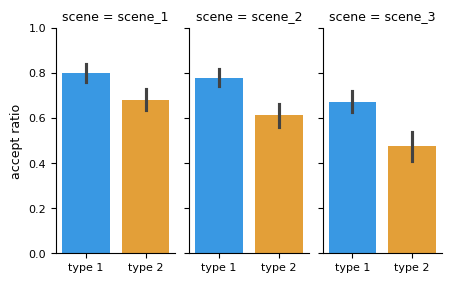

      scene driving  type  accept_mean  reject_mean  ignore_mean   n
0   scene_1    auto     1     0.836364     0.090909     0.072727  11
1   scene_1    auto     2     0.618182     0.327273     0.054545  11
2   scene_1  manual     1     0.763636     0.109091     0.127273  11
3   scene_1  manual     2     0.745455     0.145455     0.109091  11
4   scene_2    auto     1     0.813636     0.131818     0.054545  11
5   scene_2    auto     2     0.563636     0.363636     0.072727  11
6   scene_2  manual     1     0.745455     0.181818     0.072727  11
7   scene_2  manual     2     0.660606     0.251515     0.087879  11
8   scene_3    auto     1     0.781818     0.181818     0.036364  11
9   scene_3    auto     2     0.454545     0.509091     0.036364  11
10  scene_3  manual     1     0.563636     0.309091     0.127273  11
11  scene_3  manual     2     0.493939     0.360606     0.145455  11

=== Type1 vs Type2 difference within each scene ===

--- accept ---
scene_1: type1(n=22, mean=0.800, m

In [16]:
df_stats = extract_reaction_stats(data_dict)

# plot_scene_facet(df_stats)
plot_type_facet(df_stats)

summary = summarize_scene(df_stats)

# test_driving_per_scene(df_stats)
# test_scene_effect(df_stats)
# test_interaction_proxy(df_stats)
test_scene_type_diff(df_stats)

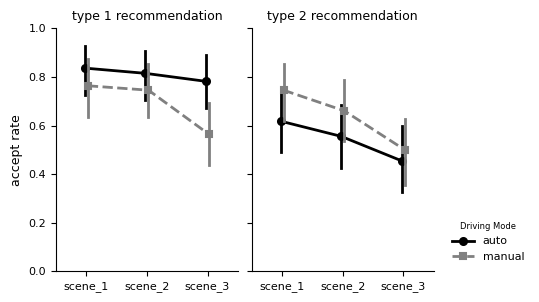

In [17]:
df_trial["driving"] = df_trial["driving"].astype("category")
df_trial["scene"] = df_trial["scene"].astype("category")
df_trial["type"] = df_trial["type"].astype("category")

# plt.figure(figsize=(3,3))

g = sns.catplot(
    data=df_trial,
    x="scene",
    y="accept",
    hue="driving",
    col="type",
    kind="point",
    dodge=True,
    errorbar=('ci', 95),
    height=3,
    aspect=0.6,
    palette=["black", "gray"],
    markers=["o", "s"],
    linestyles=["-", "--"],
    linewidth = 2.0,
)

g.set_axis_labels("", "accept rate")
g.set_titles("type {col_name} recommendation")
g._legend.set_bbox_to_anchor((1.0, 0.1))
g._legend.set_loc("lower left")
g._legend.set_title("Driving Mode")
# g.fig.suptitle(
#     "Accept Rate by Scene, Driving Mode, and Type",
#     y=1.0,
#     ha='center'
# )

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylim(0, 1)
    ax.set_yticks(np.linspace(0, 1, 6))

plt.tight_layout()
plt.show()

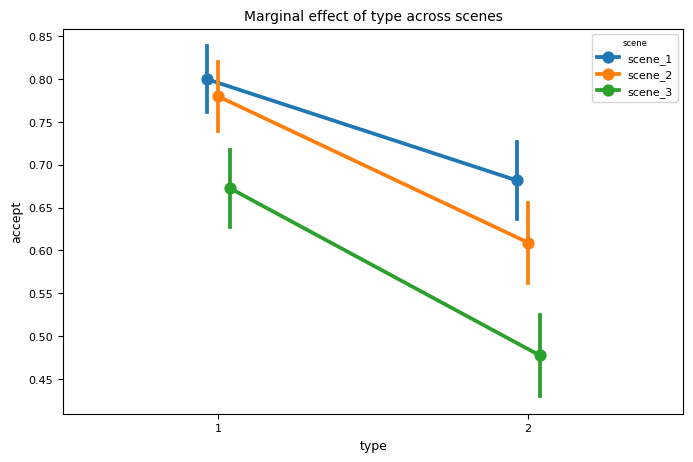

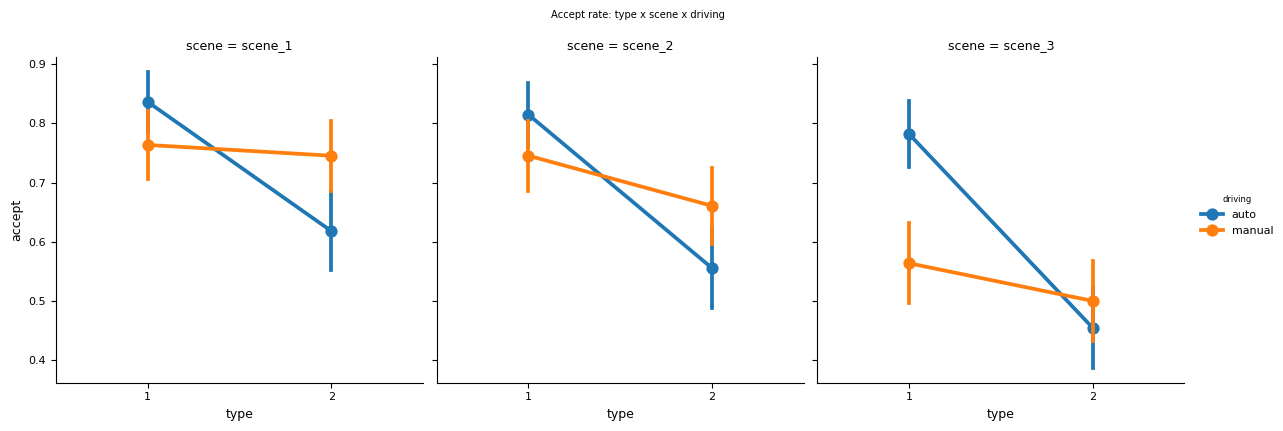

/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1900/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")
/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1900/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")
/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1900/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain

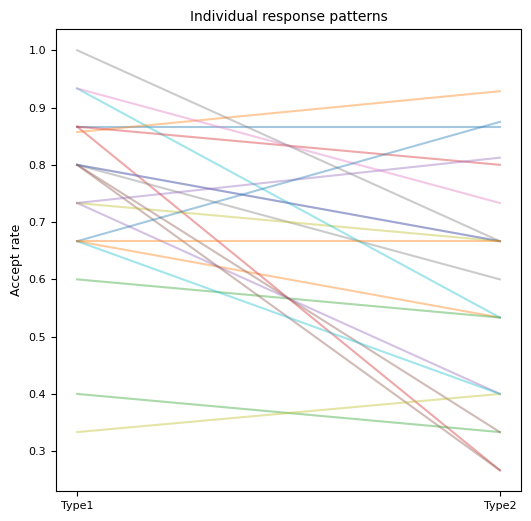

In [18]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.pointplot(
    data=df_trial,
    x="type",
    y="accept",
    hue="scene",
    dodge=True,
    errorbar="se"
)

plt.title("Marginal effect of type across scenes")
plt.show()

g = sns.catplot(
    data=df_trial,
    x="type",
    y="accept",
    hue="driving",
    col="scene",
    kind="point",
    errorbar="se",
    height=4,
    aspect=1,
)

g.fig.suptitle("Accept rate: type x scene x driving", y=1.05)
plt.show()

plt.figure(figsize=(6,6))

for sub in df_trial["sub"].unique():
    sub_df = df_trial[df_trial["sub"]==sub]
    pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")

    plt.plot([1,2], pivot.values.flatten(), alpha=0.4)

plt.xticks([1,2], ["Type1", "Type2"])
plt.ylabel("Accept rate")
plt.title("Individual response patterns")
plt.show()

## 3. Subject clustering

In [18]:
pivot = df_trial.pivot_table(
    index="sub",
    columns="type",
    values="accept",
    aggfunc="mean"
)

pivot.columns = ["accept_type1", "accept_type2"]
pivot["diff"] = pivot["accept_type1"] - pivot["accept_type2"]

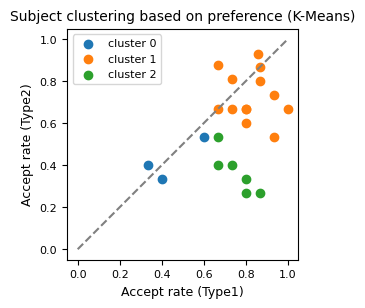

In [46]:
from sklearn.cluster import KMeans

X = pivot[["accept_type1", "accept_type2"]].values

kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
pivot["cluster"] = kmeans.labels_

plt.figure(figsize=(3,3))

for c in sorted(pivot["cluster"].unique()):
    sub_df = pivot[pivot["cluster"]==c]
    plt.scatter(
        sub_df["accept_type1"],
        sub_df["accept_type2"],
        label=f"cluster {c}"
    )

plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("Accept rate (Type1)")
plt.ylabel("Accept rate (Type2)")
# plt.xticks(np.linspace(0, 1, 11))
# plt.yticks(np.linspace(0, 1, 11))
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.title("Subject clustering based on preference (K-Means)")
plt.show()

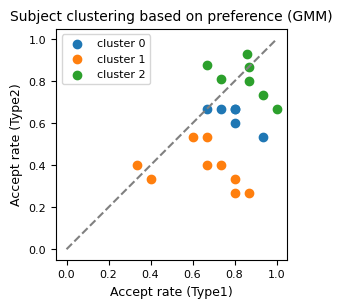

In [45]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

X = pivot[["accept_type1", "accept_type2"]].values

gmm = GaussianMixture(n_components=3, random_state=42)
pivot["cluster"] = gmm.fit_predict(X)

fig, ax = plt.subplots(figsize=(3, 3))

for c in sorted(pivot["cluster"].unique()):
    sub_df = pivot[pivot["cluster"] == c]
    ax.scatter(
        sub_df["accept_type1"],
        sub_df["accept_type2"],
        label=f"cluster {c}"
    )

ax.set_xlabel("Accept rate (Type1)")
ax.set_ylabel("Accept rate (Type2)")
ax.set_aspect("equal", adjustable="box")
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.legend()
ax.set_title("Subject clustering based on preference (GMM)")

plt.show()

In [22]:
pivot = df_trial.pivot_table(
    index="sub",
    columns="type",
    values="accept",
    aggfunc="mean"
)

pivot["diff"] = pivot[1] - pivot[2]
print(pivot)

type         1         2      diff
sub                               
1     0.866667  0.866667  0.000000
2     0.666667  0.533333  0.133333
3     0.600000  0.533333  0.066667
4     0.866667  0.266667  0.600000
5     0.733333  0.400000  0.333333
6     0.800000  0.266667  0.533333
7     0.800000  0.666667  0.133333
8     0.800000  0.600000  0.200000
9     0.733333  0.666667  0.066667
10    0.933333  0.533333  0.400000
11    0.800000  0.666667  0.133333
12    0.857143  0.928571 -0.071429
13    0.400000  0.333333  0.066667
14    0.866667  0.800000  0.066667
15    0.733333  0.812500 -0.079167
16    0.800000  0.333333  0.466667
17    0.933333  0.733333  0.200000
18    1.000000  0.666667  0.333333
19    0.333333  0.400000 -0.066667
20    0.666667  0.400000  0.266667
21    0.666667  0.875000 -0.208333
22    0.666667  0.666667  0.000000


/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1900/1211643864.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_trial.pivot_table(


# 4. Per-reaction modeling

For each reaction, we aggregate trial-level features into the following groups.

---

### Meta

- `sub_id`: subject ID (`int`)
- `scene_id`: scene ID (`int`)
- `mode`: driving mode (`int`)
- `recommendation`: recommendation code (`int`, 5 digits)
- `recommendation_category`: recommendation category (`int`, 1 digit)
- `recommendation_subcategory`: recommendation subcategory (`int`, 3 digits)

---

### Prior

These variables describe the participant’s baseline tendency and behavioral state before the current recommendation.

- `subject_prior_accept_prob_subcategory`: subject-level prior probability of accepting this recommendation subcategory (`float`)
- `mean_steering_input`: mean steering input (`float`)
- `var_steering_input`: variance of steering input (`float`)
- `mean_throttle_input`: mean throttle input (`float`)
- `var_throttle_input`: variance of throttle input (`float`)

---

### Scenario

These variables describe the current recommendation and the driving context around the reaction.

- `intensity`: intensity of the recommendation (`float`)
- `coherence`: coherence of the recommendation (`float`)
- `mean_steering_input_zscore_pre2s`: mean steering input z-score in the 2 s pre-reaction window (`float`)
- `mean_throttle_input_zscore_pre2s`: mean throttle input z-score in the 2 s pre-reaction window (`float`)

---

### Reaction

These variables describe the behavioral response to the recommendation.

- `accept`: whether the recommendation was accepted (`bool`)
- `reaction_time_ms`: reaction time in milliseconds (`float`)
- `mean_steering_input_zscore_post5s`: mean steering input z-score in the 5 s post-reaction window (`float`)
- `mean_throttle_input_zscore_post5s`: mean throttle input z-score in the 5 s post-reaction window (`float`)

---

### Evaluation

These variables describe the participant’s subjective evaluation after the reaction.

- `disturbance`: perceived disturbance (`float`)
- `satisfaction`: subjective satisfaction (`float`)
- `appropriateness`: perceived appropriateness (`float`)

---

## Dynamic Modeling Goal

We build a dynamical decision model that takes **prior** and **scenario** variables as inputs to predict whether a recommendation is **accepted**.

The model is designed to capture the competition between latent **accept** and **reject** decision states over time.

---

## Modeling Assumption

We assume that the biological time constant of the decision dynamics is the same across participants.

In other words:

- the accept-state time constant is shared across subjects
- the reject-state time constant is shared across subjects

This means that individual differences are modeled mainly through:

- prior acceptance tendency
- scenario-dependent inputs
- reaction-specific context

rather than through subject-specific intrinsic time constants.


In [177]:
df_reaction = databuilder.build_per_reaction_df(
    data_dict,
    intensity_dict = stimuli_intensity_dict,
    pre_window_ms=2000,
    post_window_ms=5000,
)

# print(df_reaction["prior_mean_throttle_input"].head())

reaction_data_dict = databuilder.build_per_reaction_data_dict(df_reaction)

## 4.1 Subcategory Disturbance, Satisfaction and Appropriateness

In [8]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

df = df_reaction.copy()

df["scene_id"] = df["scene_id"].astype("category")
df["mode"] = df["mode"].astype("category")
df["recommendation_subcategory"] = df["recommendation_subcategory"].astype("category")
df["sub_id"] = df["sub_id"].astype("category")

metrics = ["appropriateness", "disturbance", "satisfaction"]

In [35]:
overall_results = []

for metric in metrics:
    formula = f"{metric} ~ recommendation_subcategory * scene_id * mode"
    model_all = smf.mixedlm(
        formula,
        df,
        groups=df["sub_id"]
    ).fit(reml=False)

    print("\n" + "="*80)
    print(f"OVERALL MODEL FOR {metric}")
    print("="*80)
    print(model_all.summary())

    coef_table = pd.DataFrame({
        "term": model_all.params.index,
        "coef": model_all.params.values,
        "pval": model_all.pvalues.values
    })
    coef_table["metric"] = metric
    overall_results.append(coef_table)

overall_results_df = pd.concat(overall_results, ignore_index=True)


OVERALL MODEL FOR appropriateness
                                     Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 appropriateness
No. Observations:                   660                     Method:                             ML             
No. Groups:                         22                      Scale:                              2.1342         
Min. group size:                    28                      Log-Likelihood:                     -1208.5313     
Max. group size:                    31                      Converged:                          Yes            
Mean group size:                    30.0                                                                       
---------------------------------------------------------------------------------------------------------------
                                                                     Coef.  Std.Err.   z    P>|z| [0.025 0

In [48]:
per_subcat_results = []
per_subcat_models = {}

for subcat in df["recommendation_subcategory"].cat.categories:
    df_sub = df[df["recommendation_subcategory"] == subcat].copy()

    for metric in metrics:
        formula = f"{metric} ~ scene_id * mode"

        try:
            model = smf.mixedlm(
                formula,
                df_sub,
                groups=df_sub["sub_id"]
            ).fit(reml=False)

            per_subcat_models[(subcat, metric)] = model

            for term in model.params.index:
                per_subcat_results.append({
                    "subcategory": subcat,
                    "metric": metric,
                    "term": term,
                    "coef": model.params.get(term, np.nan),
                    "pval": model.pvalues.get(term, np.nan)
                })

        except Exception as e:
            print(f"Model failed for subcategory={subcat}, metric={metric}: {e}")

per_subcat_results_df = pd.DataFrame(per_subcat_results)
per_subcat_results_df.head()

def add_fdr_by_group(df_in, group_cols=("metric", "term"), p_col="pval"):
    df_out = df_in.copy()
    df_out["pval_fdr"] = np.nan

    grouped = df_out.groupby(list(group_cols), dropna=False)

    for keys, idx in grouped.groups.items():
        pvals = df_out.loc[idx, p_col].values.astype(float)
        mask = ~np.isnan(pvals)
        if mask.sum() > 0:
            corrected = multipletests(pvals[mask], method="fdr_bh")[1]
            df_out.loc[np.array(idx)[mask], "pval_fdr"] = corrected

    return df_out

per_subcat_results_df = add_fdr_by_group(per_subcat_results_df)

summary_rows = []

for subcat in df["recommendation_subcategory"].cat.categories:
    for metric in metrics:
        df_tmp = per_subcat_results_df[
            (per_subcat_results_df["subcategory"] == subcat) &
            (per_subcat_results_df["metric"] == metric)
        ].copy()

        scene_terms = df_tmp[df_tmp["term"].str.contains("scene_id", regex=False, na=False) &
                             ~df_tmp["term"].str.contains(":", regex=False, na=False)]

        mode_terms = df_tmp[df_tmp["term"].str.contains("mode", regex=False, na=False) &
                            ~df_tmp["term"].str.contains(":", regex=False, na=False)]

        interaction_terms = df_tmp[
            df_tmp["term"].str.contains("scene_id") &
            df_tmp["term"].str.contains("mode") &
            df_tmp["term"].str.contains(":")
        ]

        summary_rows.append({
            "subcategory": subcat,
            "metric": metric,
            "scene_min_p": scene_terms["pval"].min() if len(scene_terms) else np.nan,
            "scene_min_p_fdr": scene_terms["pval_fdr"].min() if len(scene_terms) else np.nan,
            "mode_min_p": mode_terms["pval"].min() if len(mode_terms) else np.nan,
            "mode_min_p_fdr": mode_terms["pval_fdr"].min() if len(mode_terms) else np.nan,
            "interaction_min_p": interaction_terms["pval"].min() if len(interaction_terms) else np.nan,
            "interaction_min_p_fdr": interaction_terms["pval_fdr"].min() if len(interaction_terms) else np.nan,
        })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["metric", "subcategory"]).reset_index(drop=True)
summary_df

,subcategory,metric,scene_min_p,scene_min_p_fdr,mode_min_p,mode_min_p_fdr,interaction_min_p,interaction_min_p_fdr
0,101,appropriateness,0.069023,0.567233,0.586982,0.838546,0.668236,0.742484
1,102,appropriateness,0.126859,0.211432,0.855873,0.855873,0.826571,0.852962
2,103,appropriateness,0.478819,0.598524,0.839172,0.855873,0.133013,0.324165
3,104,appropriateness,0.126771,0.211432,0.466125,0.838546,0.130632,0.324165
4,105,appropriateness,0.000015,0.000147,0.179713,0.838546,0.003695,0.036953
5,201,appropriateness,0.001109,0.005544,0.511115,0.838546,0.214327,0.410235
6,202,appropriateness,0.009195,0.030649,0.694265,0.855873,0.188313,0.324165
7,203,appropriateness,0.408197,0.583138,0.323308,0.838546,0.223774,0.606537
8,204,appropriateness,0.332765,0.723173,0.031415,0.314148,0.026025,0.130123
9,205,appropriateness,0.066539,0.166346,0.429795,0.838546,0.194499,0.324165


In [49]:
from itertools import combinations
from scipy.stats import ttest_rel

pairwise_rows = []

for metric in metrics:
    agg = (
        df.groupby(["sub_id", "recommendation_subcategory"], observed=True)[metric]
        .mean()
        .reset_index()
    )

    wide = agg.pivot(index="sub_id", columns="recommendation_subcategory", values=metric)

    for a, b in combinations(wide.columns, 2):
        paired = wide[[a, b]].dropna()
        if len(paired) >= 2:
            stat, pval = ttest_rel(paired[a], paired[b])
            pairwise_rows.append({
                "metric": metric,
                "subcat_a": a,
                "subcat_b": b,
                "n_subjects": len(paired),
                "mean_a": paired[a].mean(),
                "mean_b": paired[b].mean(),
                "mean_diff": (paired[a] - paired[b]).mean(),
                "pval": pval
            })

pairwise_df = pd.DataFrame(pairwise_rows)

# FDR per metric
pairwise_df["pval_fdr"] = np.nan
for metric in metrics:
    idx = pairwise_df["metric"] == metric
    if idx.sum() > 0:
        pairwise_df.loc[idx, "pval_fdr"] = multipletests(
            pairwise_df.loc[idx, "pval"],
            method="fdr_bh"
        )[1]

pairwise_df = pairwise_df.sort_values(["metric", "pval_fdr"])
pairwise_df.head(20)

,metric,subcat_a,subcat_b,n_subjects,mean_a,mean_b,mean_diff,pval,pval_fdr
3,appropriateness,101,105,12,6.694444,5.000000,1.694444,0.000691,0.009749
5,appropriateness,101,202,12,6.694444,4.666667,2.027778,0.000693,0.009749
6,appropriateness,101,203,12,6.694444,4.472222,2.222222,0.000537,0.009749
7,appropriateness,101,204,12,6.694444,4.472222,2.222222,0.000867,0.009749
4,appropriateness,101,201,12,6.694444,4.750000,1.944444,0.001724,0.015520
2,appropriateness,101,104,12,6.694444,5.583333,1.111111,0.004346,0.030956
20,appropriateness,103,202,12,5.861111,4.666667,1.194444,0.005257,0.030956
26,appropriateness,104,202,12,5.583333,4.666667,0.916667,0.005503,0.030956
8,appropriateness,101,205,12,6.694444,5.500000,1.194444,0.007798,0.038991
15,appropriateness,102,204,12,6.083333,4.472222,1.611111,0.008820,0.039692


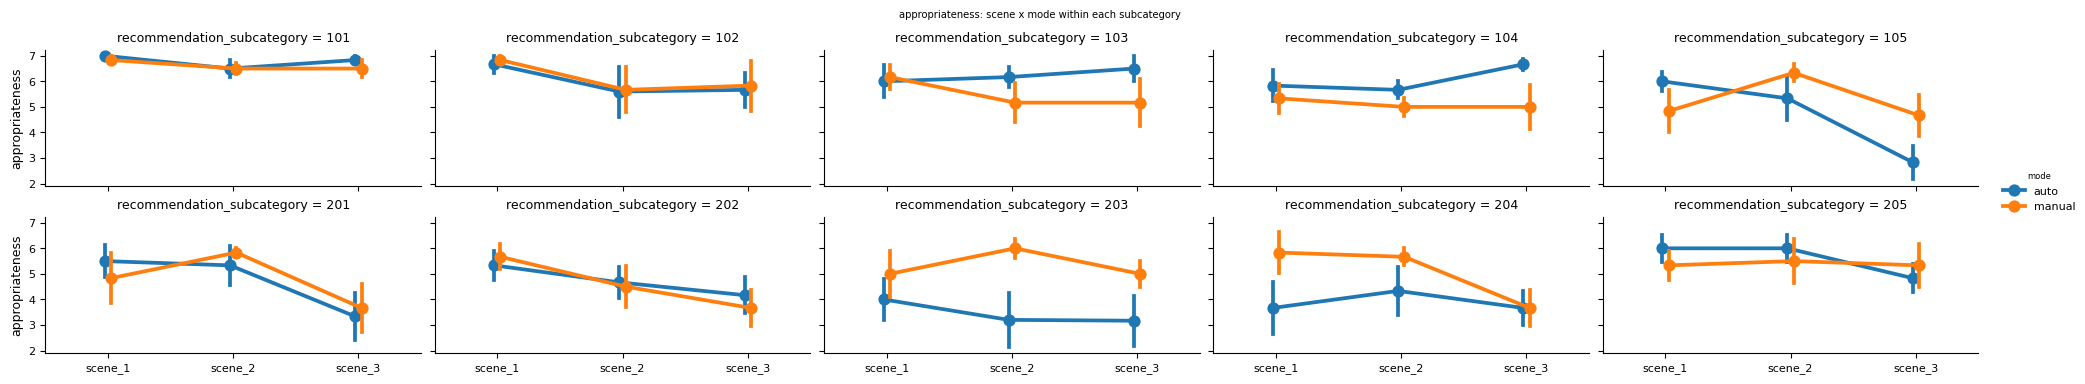

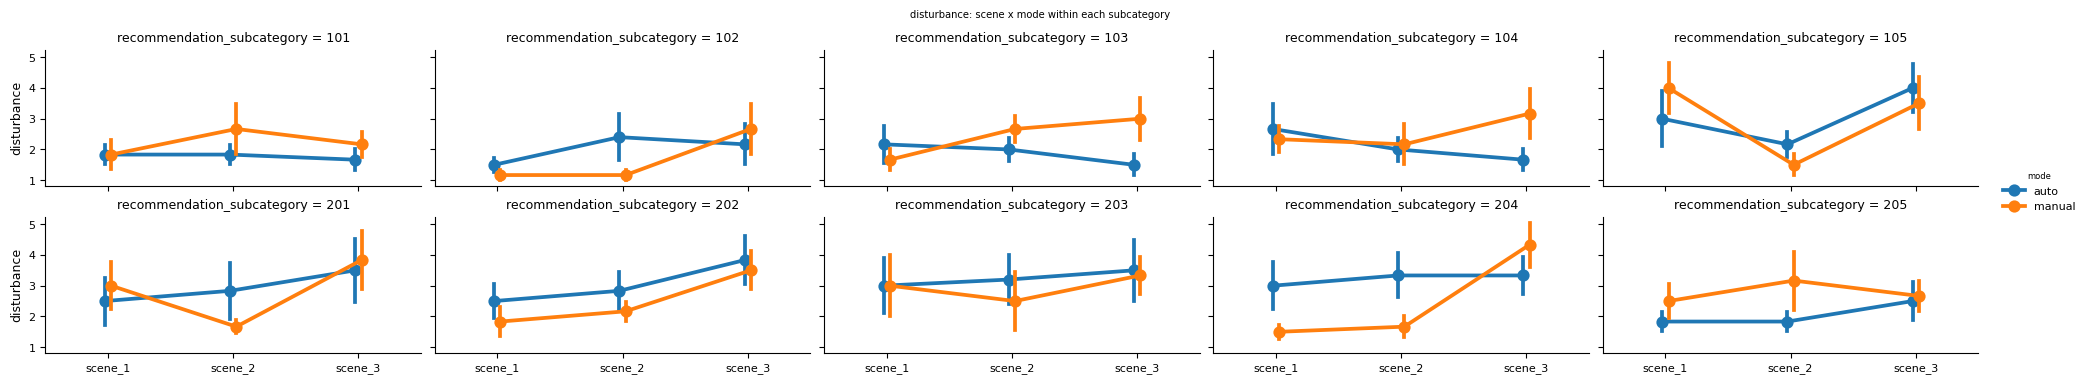

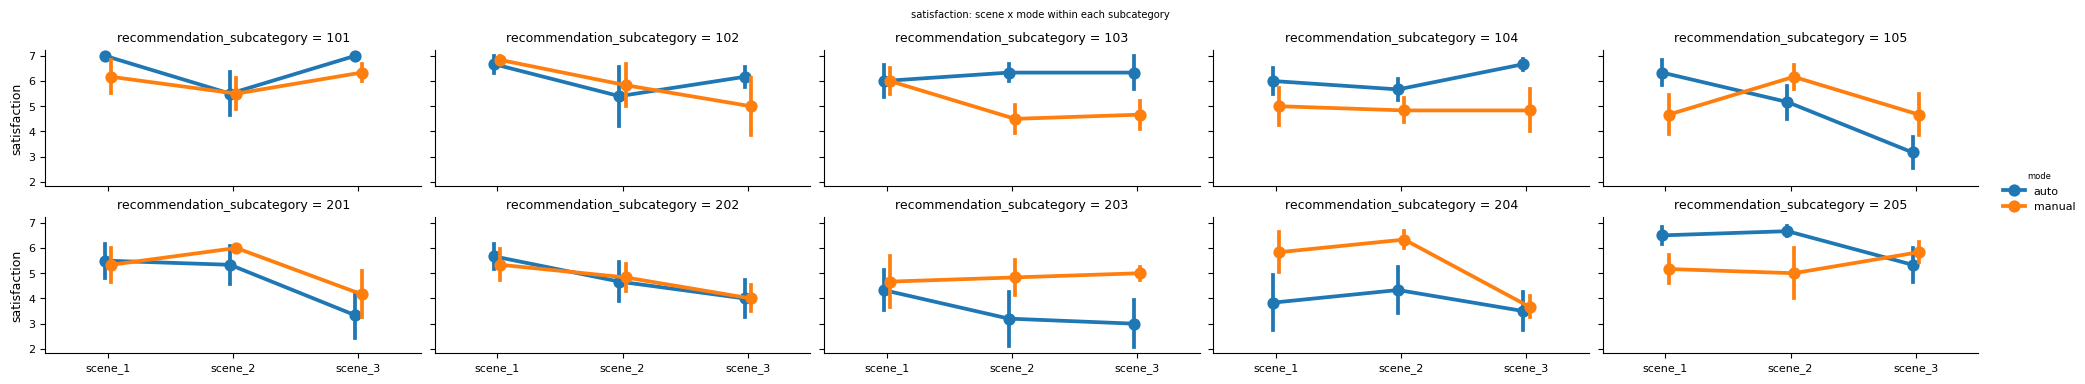

In [73]:
for metric in metrics:
    g = sns.catplot(
        data=df,
        x="scene_id",
        y=metric,
        hue="mode",
        col="recommendation_subcategory",
        kind="point",
        errorbar="se",
        dodge=True,
        col_wrap=5,
        height=2,
        aspect=2
    )
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle(f"{metric}: scene x mode within each subcategory")
    for ax in g.axes.flat:
        ax.set_xlabel("")
    plt.show()

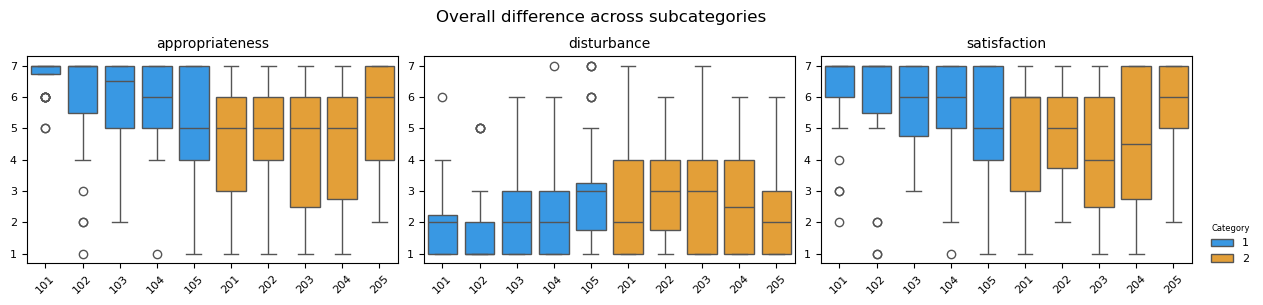

In [100]:
fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 3))

for i, metric in enumerate(metrics):
    ax = axes[i] if len(metrics) > 1 else axes

    sns.boxplot(
        data=df,
        x="recommendation_subcategory",
        y=metric,
        color="lightblue",
        hue="recommendation_category",
        palette=type_palette,
        ax=ax
    )
    # sns.stripplot(
    #     data=df,
    #     x="recommendation_subcategory",
    #     y=metric,
    #     color="black",
    #     alpha=0.25,
    #     size=3
    # )

    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    ax.set_ylabel("")
    if ax.get_legend() is not None:
        handles, labels = ax.get_legend_handles_labels()

        ax.get_legend().remove()

fig.suptitle("Overall difference across subcategories", fontsize=12)

fig.tight_layout(rect=[0, 0, 1, 1])

fig.legend(handles, labels, title="Category", loc="lower left", bbox_to_anchor=(1.0, 0.1), frameon=False)

plt.show()

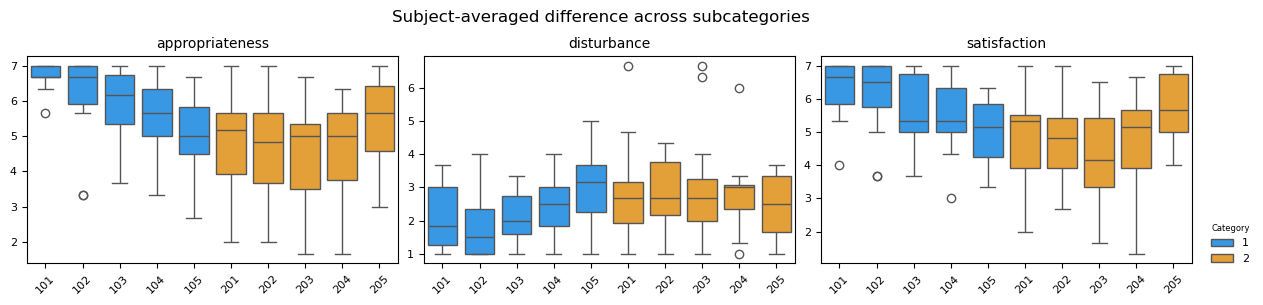

In [95]:
fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 3))

for i, metric in enumerate(metrics):
    agg = (
        df.groupby(["sub_id", "recommendation_subcategory"], observed=True)[metric]
        .mean()
        .reset_index()
    )

    agg["category"] = agg["recommendation_subcategory"].astype(int) // 100

    ax = axes[i] if len(metrics) > 1 else axes

    sns.boxplot(
        data=agg,
        x="recommendation_subcategory",
        y=metric,
        hue="category",
        palette=type_palette,
        ax=ax
    )

    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    ax.set_ylabel("")
    if ax.get_legend() is not None:
        handles, labels = ax.get_legend_handles_labels()

        ax.get_legend().remove()

fig.suptitle("Subject-averaged difference across subcategories", fontsize=12)

fig.tight_layout(rect=[0, 0, 1, 1])

fig.legend(handles, labels, title="Category", loc="lower left", bbox_to_anchor=(1.0, 0.1), frameon=False)

plt.show()

In [179]:
df_reaction[["appropriateness", "disturbance", "satisfaction"]].corr()

,appropriateness,disturbance,satisfaction
appropriateness,1.00000,-0.628580,0.879420
disturbance,-0.62858,1.000000,-0.650392
satisfaction,0.87942,-0.650392,1.000000


In [180]:
df_reaction[["disturbance", "intensity", "mean_throttle_pre2s"]].corr()

,disturbance,intensity,mean_throttle_pre2s
disturbance,1.000000,0.092295,-0.013930
intensity,0.092295,1.000000,-0.012292
mean_throttle_pre2s,-0.013930,-0.012292,1.000000


## 4.2 Baseline Model: logistic regression and svm

In [181]:
features = [
    "subject_prior_accept_prob_subcategory",
    "intensity",
    "coherence",
    "var_throttle_pre2s",
    "car_density",
    "time_pressure",
    "mode",
    # "appropriateness",
    # "disturbance",
    # "satisfaction",
]

target = "accept"

In [182]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

X = df_reaction[features].copy()
y = df_reaction[target].astype(int)

X["time_pressure"] = X["time_pressure"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.7575757575757576
AUC: 0.796875
              precision    recall  f1-score   support

           0       0.75      0.41      0.53        44
           1       0.76      0.93      0.84        88

    accuracy                           0.76       132
   macro avg       0.75      0.67      0.68       132
weighted avg       0.76      0.76      0.73       132



In [184]:
from sklearn.svm import SVC

pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(probability=True, kernel="rbf"))
])

pipe_svm.fit(X_train, y_train)

y_pred_svm = pipe_svm.predict(X_test)
y_prob_svm = pipe_svm.predict_proba(X_test)[:, 1]

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM AUC:", roc_auc_score(y_test, y_prob_svm))

SVM Accuracy: 0.7272727272727273
SVM AUC: 0.7524535123966942


In [185]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_dummy = dummy.predict(X_test)

print("Dummy Accuracy:", accuracy_score(y_test, y_dummy))

Dummy Accuracy: 0.6666666666666666


In [183]:
coef = pipe.named_steps["clf"].coef_[0]
feature_importance = pd.Series(coef, index=features).sort_values()

print(feature_importance)

time_pressure                           -0.259079
car_density                             -0.108517
var_throttle_pre2s                      -0.105449
coherence                                0.000000
mode                                     0.066295
intensity                                0.082001
subject_prior_accept_prob_subcategory    0.940763
dtype: float64


## 4.3 1d Dynamics Simulation

The latent decision state `x` evolves as:

`change in x = leak + nonlinear term + input drive + noise`

More specifically:

`dx/dt = -lam * x + a * tanh(gain * (x - theta_dyn)) + u + noise`

where:

- `lam`: how strongly the state decays back
- `a`: strength of nonlinear attraction
- `gain`: steepness of the nonlinearity
- `theta_dyn`: center of the nonlinear curve
- `u`: evidence / pressure input
- `noise`: random fluctuation

Initial state:

`x0 = kappa * logit(p0)`

Decision readout:

`p_accept = sigmoid(x_final - theta_readout)`

Important:

- `theta_dyn` is part of the dynamics
- `theta_readout` is the final decision threshold
- nullcline means `dx/dt = 0`

In [666]:
dummy_row = pd.Series({

    # ---------------- meta ----------------
    "sub_id": 0,
    "scene_id": "scene_1",
    "mode": "manual",
    "trial_id": 0,
    "recommendation": "dummy recommendation",
    "recommendation_category": 1,
    "recommendation_subcategory": 101,

    # ---------------- prior ----------------
    "subject_prior_accept_prob_subcategory": 0.5,
    "prior_mean_throttle_input": 0.0,
    "prior_var_throttle_input": 0.0,

    # ---------------- scenario ----------------
    "intensity": 0,
    "coherence": 0,
    "mean_throttle_input_zscore_pre2s": 0.0,
    "mean_throttle_pre2s": 0.0,
    "var_throttle_pre2s": 0.0,
    "car_density": 0.0,
    "time_pressure": 0,

    # ---------------- reaction ----------------
    "reaction": "ignore",
    "accept": False,
    "reaction_time_ms": np.nan,
    "mean_throttle_input_zscore_post5s": 0.0,
    "mean_throttle_post5s": 0.0,
    "var_throttle_post5s": 0.0,

    # ---------------- evaluation ----------------
    "appropriateness": 0.0,
    "disturbance": 0.0,
    "satisfaction": 0.0,

    # ---------------- bookkeeping ----------------
    "reaction__time_ms": 0.0,
    "trigger__time_ms": 0.0,
})

scene_id :scene_1, mode: manual, subcatgory: 101
===== Single Trial Demo (1D) =====
model = nonlinear_tanh
prior p0 = 0.500
x0 = 0.366
u = -0.050
lam_eff = 1.000
sigma_eff = 0.040
gain_eff = 2.500
theta_dyn = 0.000
theta_readout = 0.000
x_final = 1.938
p_accept = 0.874
predicted accept = 1
fixed points:
  x* = -2.050, stable, slope=-0.999
  x* = 0.013, unstable, slope=3.995
  x* = 1.950, stable, slope=-0.999


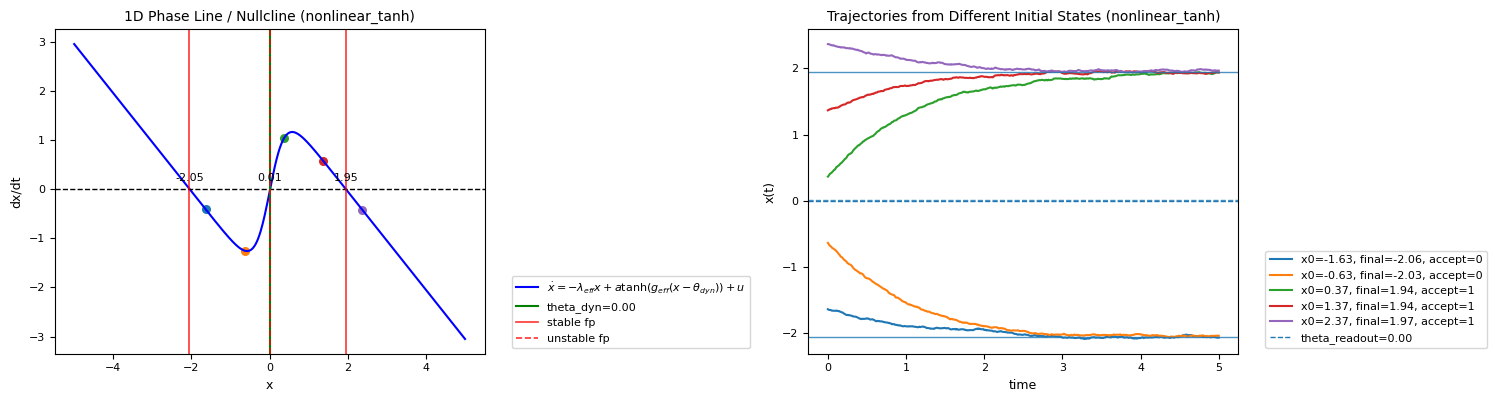

In [748]:
# row = df_reaction.iloc[4]
row = dummy_row
print(f"scene_id :{row['scene_id']}, mode: {row['mode']}, subcatgory: {row['recommendation_subcategory']}")


result = oneddynamics.run_single_trial_demo(
    row,
    model="nonlinear_tanh",
    beta_c=0.1,
    beta_i=0.1,
    beta_ci=0.1,

    gamma_throttle=0.1,
    gamma_density=0.1,
    gamma_time=0.25,
    gamma_mode=0.05,

    kappa=1.0,
    lam=1.0,
    a=2.0,
    gain=2.5,
    theta_dyn=0.0,

    sigma=0.04,
    theta_readout=0.0,
    dt=0.01,
    T=5.0,
    
    density_lam_gain=0.0,
    density_sigma_gain=0.0,
    time_gain_multiplier=1.0,
    auto_lam_multiplier=1.0,
    auto_sigma_multiplier=1.0,
)

In [285]:
df_sim = oneddynamics.simulate_dataframe_decisions(
    df_reaction,
    model="nonlinear_tanh",
    beta_c=0.1,
    beta_i=0.1,
    beta_ci=0.1,

    gamma_throttle=0.1,
    gamma_density=0.1,
    gamma_time=0.25,
    gamma_mode=0.05,

    kappa=1.0,
    lam=1.0,
    a=2.0,
    gain=2.5,
    theta_dyn=0.0,

    sigma=0.04,
    theta_readout=0.0,
    dt=0.01,
    T=5.0,
    
    density_lam_gain=0.0,
    density_sigma_gain=0.0,
    time_gain_multiplier=1.0,
    auto_lam_multiplier=1.0,
    auto_sigma_multiplier=1.0,
)

print(df_sim.head())
print((df_sim["accept_pred"] == df_sim["accept_true"]).mean())

   idx        x0         u  lam_eff  sigma_eff  gain_eff   x_final  \
0    0  1.232636  0.050727      1.0       0.04       2.5  2.055262   
1    1  2.801784  0.053818      1.0       0.04       2.5  2.021060   
2    2  3.176280  0.082727      1.0       0.04       2.5  2.102066   
3    3  1.746481  0.072000      1.0       0.04       2.5  2.080634   
4    4  1.766508  0.066909      1.0       0.04       2.5  2.105837   

   p_accept_pred  accept_pred  n_fixed_points            fixed_points  \
0       0.886478            1               3  -1.9490,-0.0127,2.0506   
1       0.882991            1               3  -1.9459,-0.0135,2.0537   
2       0.891104            1               3  -1.9170,-0.0207,2.0826   
3       0.889007            1               3  -1.9277,-0.0180,2.0719   
4       0.891469            1               3  -1.9328,-0.0167,2.0668   

   accept_true  
0            1  
1            1  
2            1  
3            1  
4            1  
0.7363636363636363


In [188]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df_sim["accept_true"], df_sim["accept_pred"])
print(cm)

[[ 88 130]
 [ 47 395]]


## 4.4 2d dynamics

The latent decision states \(x\) (accept) and \(y\) (reject) evolve as:

`change in state = leak + nonlinear term + input drive + noise`

---

### Dynamics

For accept state:

`dx/dt = -lam_x * x + phi_x(x + w_xy * y) + f_x + noise_x`

For reject state:

`dy/dt = -lam_y * y + phi_y(y + w_yx * x) + f_y + noise_y`

---

### Nonlinearity (Cubic)

`phi(z) = z - a * z^3`

- creates saturation and multi-stability  
- allows curved nullclines and attractor competition  

---

### Inputs (Drives)

Accept drive:

`f_x = alpha_prior * logit(p0)
     + alpha_coherence * coherence
     + alpha_intensity * intensity
     + alpha_ci * coherence * intensity
     + alpha_density * car_density`

Reject drive:

`f_y = beta_pressure * effective_pressure
     + beta_density * car_density
     + beta_time_pressure * time_pressure
     + beta_low_coherence * (1 - coherence)
     + beta_prior * (-logit(p0))`

---

### Context Modulation

`effective_pressure = pressure`

- reduced in auto mode via `auto_pressure_reduction`
- scaled by:
  - `density_pressure_gain`
  - `time_pressure_gain`

---

### Initial State

`x0 = kappa * logit(p0)`  
`y0 = -kappa * logit(p0)`

---

### Decision Readout

`decision = accept if (x_final - y_final) > theta`

or probabilistic:

`p_accept = sigmoid(x_final - y_final - theta)`

---

### Key Parameters

- `lam_x, lam_y`: decay (leak)
- `w_xy, w_yx`: cross-coupling (competition / excitation)
- `a`: cubic nonlinearity strength
- `sigma_x, sigma_y`: noise level
- `theta`: decision threshold

---

### Important

- competition is **implicit via coupling (w_xy, w_yx)**  
- nonlinearity shapes **attractor landscape**  
- prior enters both:
  - initial condition  
  - asymmetric drives (f_x vs f_y)  
- system outcome depends on **fixed points + trajectory**

---

### Nullcline

Nullcline is defined as:

`dx/dt = 0` and `dy/dt = 0`

Their intersection gives **fixed points** (decision attractors).


scene_id :scene_2, mode: 0, subcatgory: 202
===== Single Trial Demo (2D) =====
prior_accept_prob = 0.267
coherence = 0.000
intensity = 0.369
throttle_pressure = 0.000
car_density = 0.800
time_pressure = 0
mode = manual
effective_pressure = 0.080
accept drive f_x = 0.369
reject drive f_y = 0.088
initial state = (-0.249, 0.249)
fixed point = (-0.190, 0.373)
final state = (-0.905, 1.031)
final diff x-y = -1.936
p_accept = 0.126
accept_pred = 0


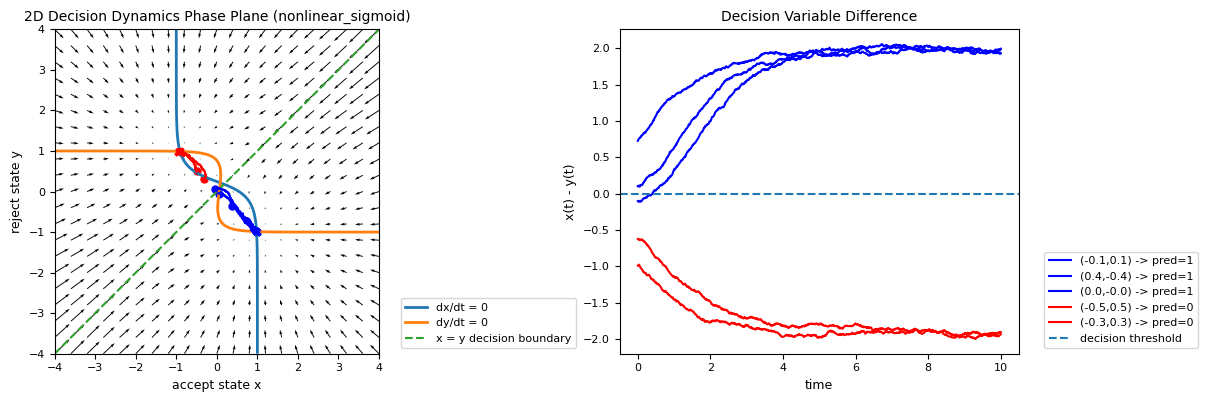

In [775]:
row = df_reaction.iloc[100]
# row = dummy_row
print(f"scene_id :{row['scene_id']}, mode: {row['mode']}, subcatgory: {row['recommendation_subcategory']}")

demo = twoddynamics.run_single_trial_demo_2d(
    row,
    auto_pressure_reduction=0.05,
    density_pressure_gain=0.1,
    time_pressure_gain=0.25,

    alpha_coherence=0.5,
    alpha_intensity=1,
    alpha_ci=0.8,

    beta_pressure=0.1,
    beta_density=0.1,
    beta_time_pressure=0.25,

    k_init=1.0,
    lam_x=1.0,
    lam_y=1.0,
    w_xy=1.5,
    w_yx=1.5,
    sigma_x=0.04,
    sigma_y=0.04,
    T=10.0,
    decision_threshold=0.0,

    model="nonlinear_sigmoid",
)

In [774]:
df_type_two = df_reaction[df_reaction["recommendation_category"] == 2]

df_sim = twoddynamics.simulate_dataframe_2d(
    df_reaction,
    
    auto_pressure_reduction=0.05,
    density_pressure_gain=0.1,
    time_pressure_gain=0.25,

    alpha_coherence=0.0,
    alpha_intensity=0.5,
    alpha_ci=0.8,

    beta_pressure=0.1,
    beta_density=0.1,
    beta_time_pressure=0.25,

    k_init=2.5,
    lam_x=1.0,
    lam_y=1.0,
    w_xy=2.5,
    w_yx=2.5,
    sigma_x=0.04,
    sigma_y=0.04,
    T=10.0,
    decision_threshold=0.0,

    model="nonlinear_sigmoid",
)
# print(df_sim.head())

valid = df_sim.dropna(subset=["accept_true"])
acc = (valid["accept_pred"] == valid["accept_true"]).mean()
print("original acceptance rate =", valid["accept_true"].mean())
print("accuracy =", acc)

original acceptance rate = 0.6696969696969697
accuracy = 0.7378787878787879


In [359]:
from scipy.optimize import differential_evolution

param_names = [
    "alpha_ci",
    "w_xy", "w_yx", "lam_x", "lam_y"
]

bounds = [
    (0.2, 1.5),   # alpha_ci
    (0.5, 4.0),   # w_xy
    (0.5, 4.0),   # w_yx
    (0.6, 1.6),   # lam_x
    (0.6, 1.6),   # lam_y
]

fixed_params = {
    "auto_pressure_reduction": 0.05,
    "density_pressure_gain": 0.1,
    "time_pressure_gain": 0.25,

    "alpha_coherence": 0.0,
    "alpha_intensity": 0.1,
    "alpha_density": 0.0,

    "beta_pressure": 0.1,
    "beta_density": 0.1,
    "beta_time_pressure": 0.25,
    "beta_low_coherence": 1.0,

    "k_init": 2.5,
    "sigma_x": 0.04,
    "sigma_y": 0.04,
    "T": 10.0,
    "decision_threshold": 0.0,

    "model": "nonlinear_sigmoid",
}

def objective(vec):
    params = dict(fixed_params)
    for k, v in zip(param_names, vec):
        params[k] = float(v)

    df_sim = twoddynamics.simulate_dataframe_2d(df_reaction, **params)
    valid = df_sim.dropna(subset=["accept_true"]).copy()

    if len(valid) == 0:
        return 1e6

    metrics = twoddynamics.compute_objective(valid)

    return -metrics["score"]

result = differential_evolution(
    objective,
    bounds=bounds,
    seed=123,
    maxiter=30,
    popsize=10,
    polish=True,
    disp=True,
)

best_vec = result.x
best_params = dict(fixed_params)
for k, v in zip(param_names, best_vec):
    best_params[k] = float(v)

print(best_params)
print("best objective =", -result.fun)

differential_evolution step 1: f(x)= -0.5582353853198431
differential_evolution step 2: f(x)= -0.5582353853198431
differential_evolution step 3: f(x)= -0.5585021423081326
differential_evolution step 4: f(x)= -0.5595959837068849
differential_evolution step 5: f(x)= -0.5595959837068849
Polishing solution with 'L-BFGS-B'
{'auto_pressure_reduction': 0.05, 'density_pressure_gain': 0.1, 'time_pressure_gain': 0.25, 'alpha_coherence': 0.0, 'alpha_intensity': 0.1, 'alpha_density': 0.0, 'beta_pressure': 0.1, 'beta_density': 0.1, 'beta_time_pressure': 0.25, 'beta_low_coherence': 1.0, 'k_init': 2.5, 'sigma_x': 0.04, 'sigma_y': 0.04, 'T': 10.0, 'decision_threshold': 0.0, 'model': 'nonlinear_sigmoid', 'alpha_ci': 0.8457572330986038, 'w_xy': 3.932039380060237, 'w_yx': 0.5759557138820077, 'lam_x': 0.9334244171845405, 'lam_y': 1.166715386029692}
best objective = 0.5595959837068849


In [436]:
valid = df_sim.dropna(subset=["accept_true"]).copy()

print("true accept rate =", valid["accept_true"].mean())
print("pred accept rate =", valid["accept_pred"].mean())

cm = pd.crosstab(
    valid["accept_true"],
    valid["accept_pred"],
    rownames=["true"],
    colnames=["pred"],
    dropna=False
)
print(cm)

true accept rate = 0.6815642458100558
pred accept rate = 0.6983240223463687
pred   0    1
true         
0     67   47
1     41  203


In [435]:
valid = df_sim.dropna(subset=["accept_true"]).copy()

print(valid[["f_x", "f_y"]].describe())
print("mean f_x =", valid["f_x"].mean())
print("mean f_y =", valid["f_y"].mean())
print("mean f_x - f_y =", (valid["f_x"] - valid["f_y"]).mean())

              f_x         f_y
count  358.000000  358.000000
mean     0.465678    0.216485
std      0.407717    0.906544
min     -0.390872   -1.544250
25%      0.204295   -0.415626
50%      0.458872    0.091574
75%      0.778244    0.828633
max      1.304402    2.190328
mean f_x = 0.4656778566930364
mean f_y = 0.2164847439459043
mean f_x - f_y = 0.24919311274713218
